In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from compressibleSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 256
dim = 2
L = 2
n_h = 4

gamma = 5/3
rho0 = 1
nu_visc = 0.0005

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros(dim, device=device, dtype=dtype)
domain.max = torch.ones(dim, device=device, dtype=dtype) * 2 * np.pi

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False


In [4]:
compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)

In [5]:
nu_inviscid = alphaToNu(0.01, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha_effective = nuToAlpha(nu_visc, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
print(f"nu_inviscid: {nu_inviscid}, alpha_effective: {alpha_effective}")

nu_inviscid: 0.0012271849438548089, alpha_effective: 0.004074365502150067


In [6]:
k = 2
u_mag = 1
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

# compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * compressibleSystem.state.positions[:,1] + phaseShift_y)
# compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * compressibleSystem.state.positions[:,1] + phaseShift_y)

compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)


In [7]:
ke0 = compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim=1)**2 * 0.5
m_total = compressibleSystem.state.masses.sum().cpu().item()
# kineticEnergy = np.array([ke.cpu().item() for ke in kes]).sum()

domainL = config.domain.max[0].cpu().item() - config.domain.min[0].cpu().item()
Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
# print(f"Theoretical initial kinetic energy: {Ek0_theoretical:.6g}")
# print(f"Initial kinetic energy from simulation: {ke0.sum().cpu().item():.6g}")
print(f'Difference: {abs(Ek0_theoretical - ke0.sum().cpu().item()):.6g}')

Difference: 1.06768e-06


Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 2.62 ms  (cached)
Module sphWarpCore.operations_grid.wp_interpolate_grid bde6e7c load on device 'cuda:0' took 3.26 ms  (cached)
Module sphWarpCore.operations_grid.wp_interpolate_grid 2282a2d load on device 'cuda:0' took 6.75 ms  (cached)


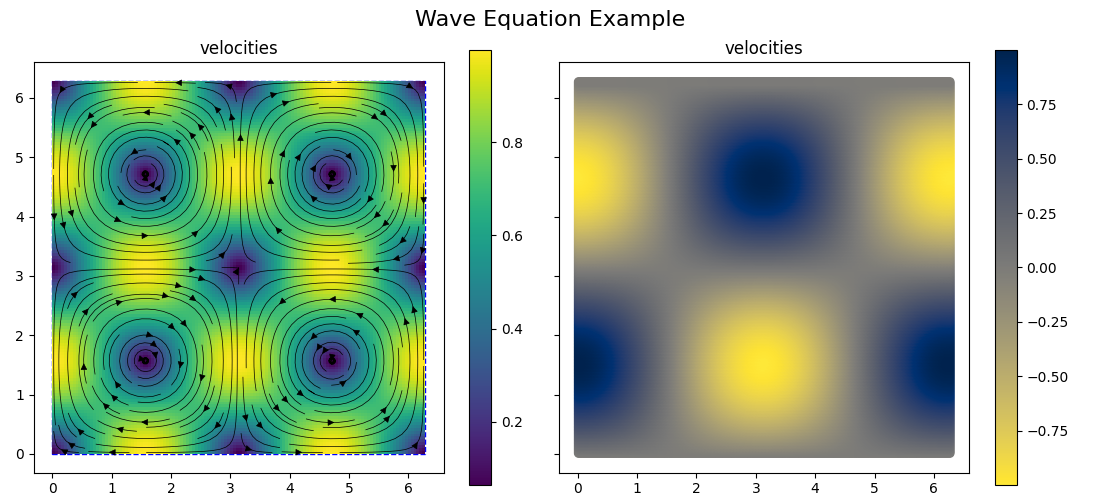

In [8]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 32
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 128,
                streamLines = True
            ),
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.y,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [9]:
runningState = compressibleSystem.initializeNewState()
from compressibleSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0008, device='cuda:0')


In [10]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 16
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [ ]:
runningState = compressibleSystem.initializeNewState()
ke = torch.sum(0.5 * runningState.state.densities * torch.sum(runningState.state.velocities**2, dim=1)) / torch.sum(runningState.state.densities)

schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.nu = 0.01

In [12]:

t_limit = 2.0
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if i % 60 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break


ts = np.arange(len(kes)) * config.dt.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])
E_k0 = kineticEnergy[0]

# Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
mask = (ts > 0) & (kineticEnergy > 0)
slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
nu_eff = -slope / (4 * ktgv**2)

  0%|          | 0/2422 [00:00<?, ?it/s]

Module sphWarpCore.renorm.wp_covariance 58ede18 load on device 'cuda:0' took 5.57 ms  (cached)
Module sphWarpCore.operations.wp_gradient 2d3b13a load on device 'cuda:0' took 5.24 ms  (cached)
Module compressibleSPH.modules.deltaSPH.wp_densityDelta bff23b3 load on device 'cuda:0' took 5.25 ms  (cached)
Module compressibleSPH.modules.deltaSPH.wp_viscosityDelta 58bfbac load on device 'cuda:0' took 3.83 ms  (cached)
Module sphWarpCore.operations.wp_divergence 7313a53 load on device 'cuda:0' took 4.46 ms  (cached)
Module compressibleSPH.modules.pressure.wp_surfaceAware 984a4fa load on device 'cuda:0' took 3.66 ms  (cached)
Module sphWarpCore.operations.wp_density f0357bf load on device 'cuda:0' took 3.07 ms  (cached)
Module compressibleSPH.sample.wp_deltaShift 2c9a194 load on device 'cuda:0' took 5.61 ms  (cached)


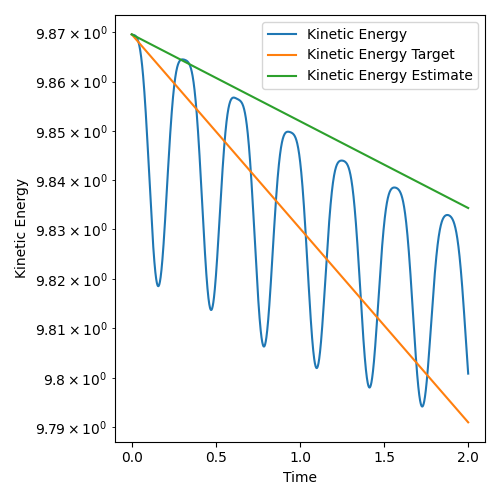

: 

In [ ]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)

ts = np.arange(len(kes)) * config.dt.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])

nu = schemeConfig.diffusionParams.viscidNu

Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2

# For u ~ exp(-2*nu*k_mode^2*t), kinetic energy decays as exp(-4*nu*k_mode^2*t).
E_kestimate = Ek0_theoretical * np.exp(-4 * ts * (ktgv**2) * nu_eff)
E_ktarget = Ek0_theoretical * np.exp(-4 * ts * (ktgv**2) * nu)

axis[0,0].plot(ts, kineticEnergy, label='Kinetic Energy')
axis[0,0].plot(ts, E_ktarget, label='Kinetic Energy Target')
axis[0,0].plot(ts, E_kestimate, label='Kinetic Energy Estimate')
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Kinetic Energy')
axis[0,0].legend()

axis[0,0].set_yscale('log')

fig.tight_layout()

In [ ]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [ ]:
# ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
# shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');